<a href="https://colab.research.google.com/github/tezendrax/Deep-Learning-Labs/blob/main/DL_Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [119]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [87]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

DATA_DIR = "./data"

# Training dataset
train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    transform=transform,
    download=True
)

# Test dataset
test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    transform=transform,
    download=True
)

print("Training samples:", len(train_dataset))
print("Test samples    :", len(test_dataset))
print("Dataset location:", DATA_DIR)

Training samples: 60000
Test samples    : 10000
Dataset location: ./data


In [88]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Selected device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Selected device: cpu


In [89]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

print("Training batches:", len(train_loader))
print("Test batches    :", len(test_loader))

Training batches: 469
Test batches    : 79


### Visualize a Batch of Training Images

Let's get one batch of images and their corresponding labels from the `train_loader` and visualize them. Since the images were normalized, we'll need to reverse the normalization to display them correctly.

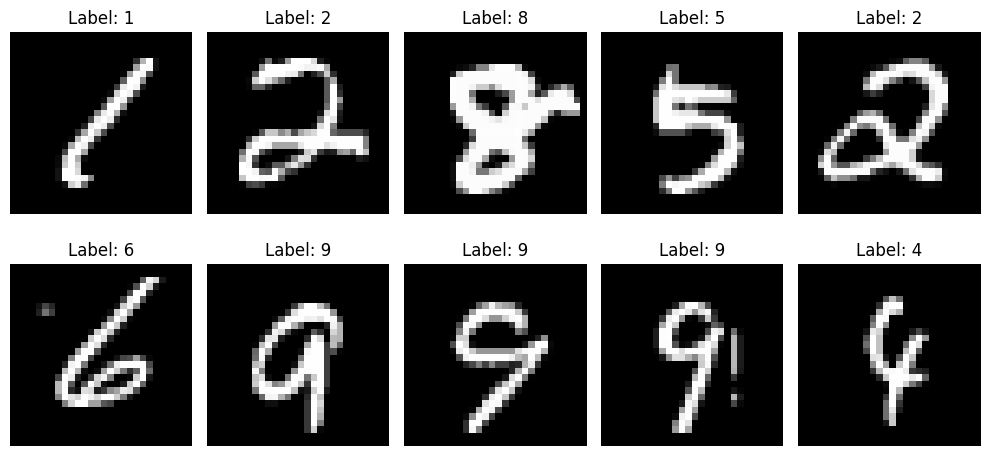

In [90]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()

    # Undo normalization for display
    img = img * 0.3081 + 0.1307
    img = np.clip(img, 0, 1)

    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [91]:
# now we will flaten the image and pass it to input to nn
sample_batch = images
print("Before flattening:", sample_batch.shape)
flatten_batch = sample_batch.view(sample_batch.shape[0], -1)
print("After flattening:", flatten_batch.shape)

Before flattening: torch.Size([128, 1, 28, 28])
After flattening: torch.Size([128, 784])


In [92]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(  # Corrected typo from self.netwok to self.network
            nn.Linear(784, 256),  # Changed from 512 to 256
            nn.ReLU(),
            nn.Linear(256, 128),    # Adjusted input from 512 to 256
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)
Model = MLP().to(device)
print(Model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [93]:
total_parameters = sum(
    parameter.numel()
    for parameter in Model.parameters() # Changed 'model' to 'Model'
    if parameter.requires_grad
)

print("Total trainable parameters:", total_parameters)

print("\nParameter details:")
for name, parameter in Model.named_parameters(): # Changed 'model' to 'Model'
    print(
        f"{name:25s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"count={parameter.numel()}"
    )

Total trainable parameters: 235146

Parameter details:
network.0.weight          shape=(256, 784)         count=200704
network.0.bias            shape=(256,)             count=256
network.2.weight          shape=(128, 256)         count=32768
network.2.bias            shape=(128,)             count=128
network.4.weight          shape=(10, 128)          count=1280
network.4.bias            shape=(10,)              count=10


In [94]:
# Define the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(Model.parameters(), lr=0.001)

print("Loss function:", loss_fn)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


The `CrossEntropyLoss` has been set as the loss function, and the `Adam` optimizer with a learning rate of 0.001 is ready to be used for training.

In [95]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = Model(images) # Changed 'model' to 'Model'

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

print("\nFirst image logits:")
print(outputs[0])

print("\nPredicted digit:", outputs[0].argmax().item())
print("Actual digit   :", labels[0].item())

Input shape : torch.Size([128, 1, 28, 28])
Output shape: torch.Size([128, 10])

First image logits:
tensor([ 0.1094, -0.0795, -0.0336, -0.1422, -0.1039, -0.0010,  0.0959, -0.0839,
        -0.1504,  0.0256])

Predicted digit: 0
Actual digit   : 9


In [96]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total trainable parameters:", total_parameters)

print("\nParameter details:")
for name, parameter in model.named_parameters():
    print(
        f"{name:25s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"count={parameter.numel()}"
    )

Total trainable parameters: 269322

Parameter details:
sequential_layers.0.weight shape=(256, 784)         count=200704
sequential_layers.0.bias  shape=(256,)             count=256
sequential_layers.2.weight shape=(256, 256)         count=65536
sequential_layers.2.bias  shape=(256,)             count=256
sequential_layers.4.weight shape=(10, 256)          count=2560
sequential_layers.4.bias  shape=(10,)              count=10


In [97]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

print("\nFirst image logits:")
print(outputs[0])

print("\nPredicted digit:", outputs[0].argmax().item())
print("Actual digit   :", labels[0].item())

Input shape : torch.Size([128, 1, 28, 28])
Output shape: torch.Size([128, 10])

First image logits:
tensor([ 0.0891, -0.0130, -0.2782, -0.1185,  0.0080,  0.0232, -0.0263, -0.0182,
        -0.1000,  0.0474])

Predicted digit: 0
Actual digit   : 8


In [98]:
# Loss function

criterion = nn.CrossEntropyLoss()

loss = criterion(outputs, labels)

print("Loss for the current batch:", loss.item())

Loss for the current batch: 2.284745931625366


In [99]:
LEARNING_RATE = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [100]:
optimizer.zero_grad()

outputs = model(images)
loss = criterion(outputs, labels)

loss.backward()

print("Loss:", loss.item())

print("\nGradient information:")
for name, parameter in model.named_parameters():
    if parameter.grad is not None:
        print(
            f"{name:25s} "
            f"shape={tuple(parameter.grad.shape)} "
            f"mean={parameter.grad.mean().item():.6f}"
        )

Loss: 2.284745931625366

Gradient information:
sequential_layers.0.weight shape=(256, 784) mean=0.000010
sequential_layers.0.bias  shape=(256,) mean=-0.000005
sequential_layers.2.weight shape=(256, 256) mean=-0.000022
sequential_layers.2.bias  shape=(256,) mean=-0.000123
sequential_layers.4.weight shape=(10, 256) mean=0.000000
sequential_layers.4.bias  shape=(10,) mean=0.000000


In [101]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # 1. Clear previous gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Calculate loss
        loss = criterion(outputs, labels)

        # 4. Backpropagation
        loss.backward()

        # 5. Update parameters
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

In [102]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

In [103]:
# Train the model

EPOCHS = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

for epoch in range(1, EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.2f}%"
    )

Epoch [01/10] | Train Loss: 0.2542 | Train Acc: 92.44% | Test Loss: 0.1184 | Test Acc: 96.23%
Epoch [02/10] | Train Loss: 0.0976 | Train Acc: 97.03% | Test Loss: 0.0902 | Test Acc: 97.06%
Epoch [03/10] | Train Loss: 0.0672 | Train Acc: 97.94% | Test Loss: 0.0836 | Test Acc: 97.47%
Epoch [04/10] | Train Loss: 0.0491 | Train Acc: 98.40% | Test Loss: 0.0704 | Test Acc: 97.75%
Epoch [05/10] | Train Loss: 0.0380 | Train Acc: 98.75% | Test Loss: 0.0683 | Test Acc: 97.86%
Epoch [06/10] | Train Loss: 0.0289 | Train Acc: 99.03% | Test Loss: 0.0759 | Test Acc: 98.03%
Epoch [07/10] | Train Loss: 0.0308 | Train Acc: 98.91% | Test Loss: 0.0791 | Test Acc: 97.72%
Epoch [08/10] | Train Loss: 0.0225 | Train Acc: 99.22% | Test Loss: 0.0889 | Test Acc: 97.75%
Epoch [09/10] | Train Loss: 0.0207 | Train Acc: 99.31% | Test Loss: 0.0850 | Test Acc: 97.91%
Epoch [10/10] | Train Loss: 0.0183 | Train Acc: 99.41% | Test Loss: 0.0894 | Test Acc: 97.72%


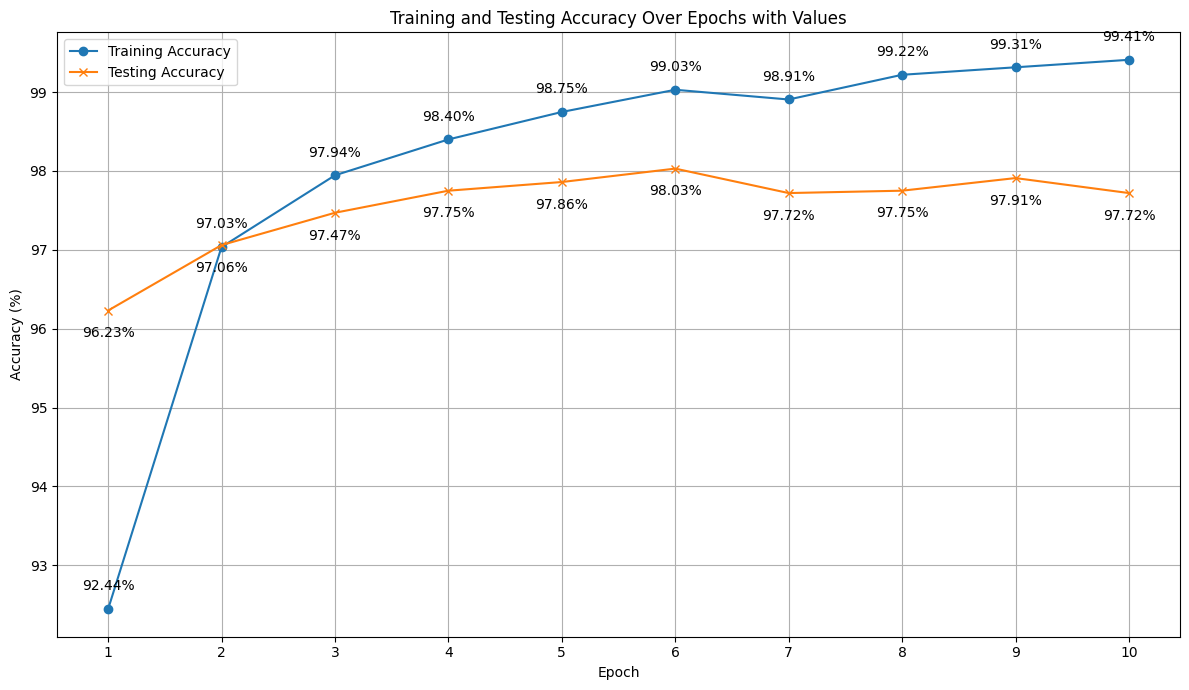

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.plot(range(1, EPOCHS + 1), history['train_accuracy'], label='Training Accuracy', marker='o')
plt.plot(range(1, EPOCHS + 1), history['test_accuracy'], label='Testing Accuracy', marker='x')

for i, (train_acc, test_acc) in enumerate(zip(history['train_accuracy'], history['test_accuracy'])):

    plt.text(i + 1, train_acc + 0.2, f'{train_acc:.2f}%', ha='center', va='bottom', fontsize=10)

    plt.text(i + 1, test_acc - 0.2, f'{test_acc:.2f}%', ha='center', va='top', fontsize=10)

plt.title('Training and Testing Accuracy Over Epochs with Values')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.xticks(range(1, EPOCHS + 1))
plt.tight_layout()
plt.show()

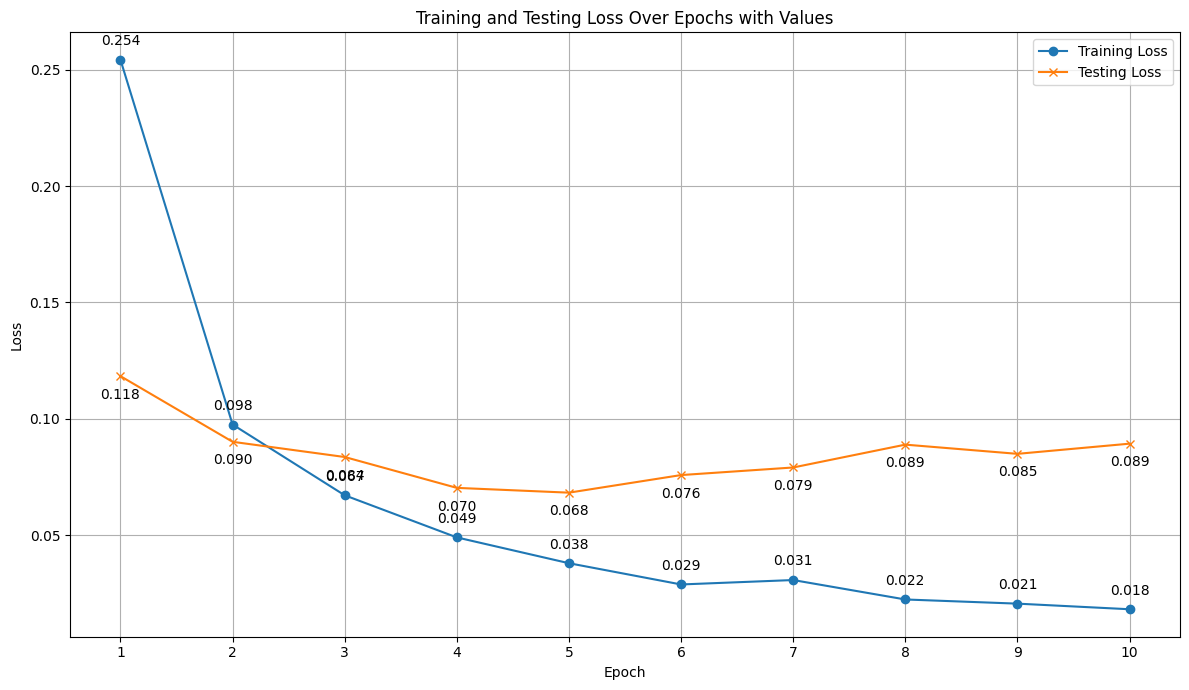

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Training Loss', marker='o')
plt.plot(range(1, EPOCHS + 1), history['test_loss'], label='Testing Loss', marker='x')

for i, (train_loss, test_loss) in enumerate(zip(history['train_loss'], history['test_loss'])):

    plt.text(i + 1, train_loss + 0.005, f'{train_loss:.3f}', ha='center', va='bottom', fontsize=10)

    plt.text(i + 1, test_loss - 0.005, f'{test_loss:.3f}', ha='center', va='top', fontsize=10)

plt.title('Training and Testing Loss Over Epochs with Values')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(range(1, EPOCHS + 1))
plt.tight_layout()
plt.show()

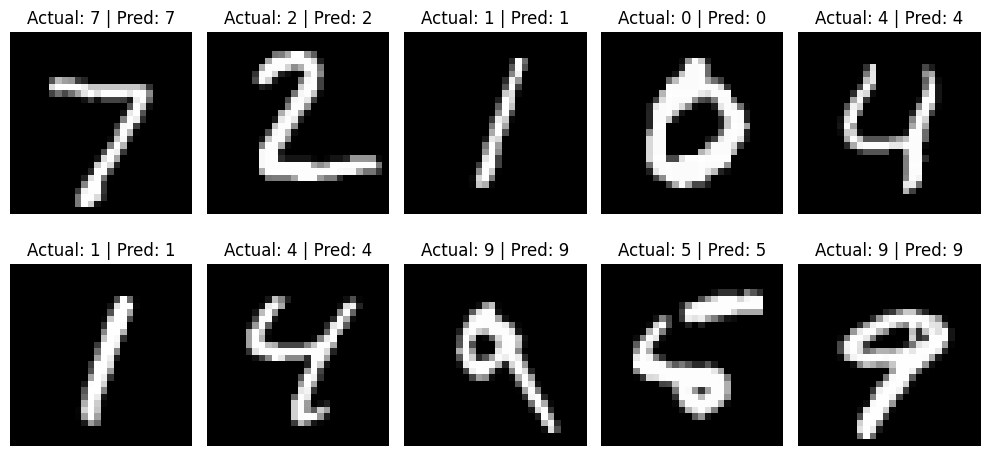

In [116]:
# Display predictions

images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    outputs = model(images.to(device))
    predictions = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()

    # Undo normalization
    img = img * 0.3081 + 0.1307
    img = np.clip(img, 0, 1)

    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"Actual: {labels[i].item()} | "
        f"Pred: {predictions[i].item()}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [117]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_predictions.extend(predictions)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

print("Total test predictions:", len(all_predictions))

Total test predictions: 10000


Number of misclassified images: 228


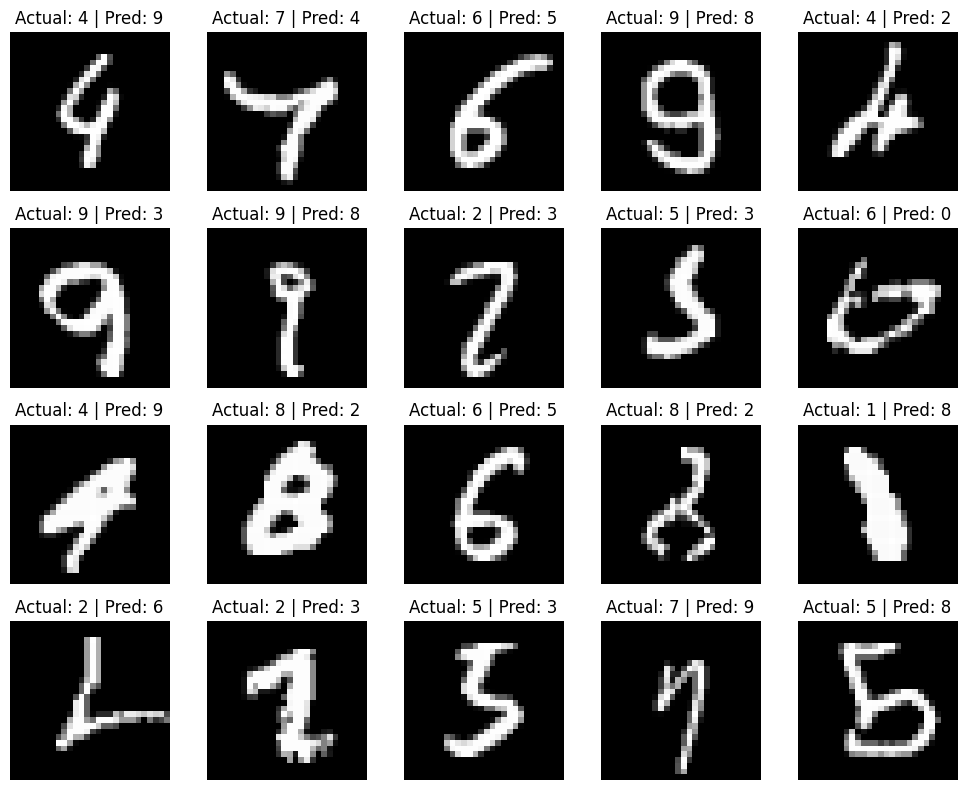

In [118]:
# Misclassified examples

wrong_indices = np.where(all_labels != all_predictions)[0]

print("Number of misclassified images:", len(wrong_indices))

num_examples = min(20, len(wrong_indices))

fig, axes = plt.subplots(4, 5, figsize=(10, 8))

for plot_index in range(num_examples):
    data_index = wrong_indices[plot_index]

    image, label = test_dataset[data_index]

    img = image.squeeze().numpy()

    # Undo normalization
    img = img * 0.3081 + 0.1307
    img = np.clip(img, 0, 1)

    axes.flat[plot_index].imshow(img, cmap="gray")
    axes.flat[plot_index].set_title(
        f"Actual: {label} | "
        f"Pred: {all_predictions[data_index]}"
    )
    axes.flat[plot_index].axis("off")

for ax in axes.flat[num_examples:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
